# Spatial PCD Data Release

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import anndata as ad
import scanpy as sc
import cupy as cp
from sklearn.neighbors import KNeighborsClassifier

import time
import rapids_singlecell as rsc

import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True, 
    pool_allocator=True,  
    devices=0  
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=14,
    dpi_save=200,
    figsize=(6,6),
    format='png'
)

In [3]:
adata = sc.read_h5ad('../files/raw-all-tissdiss.h5ad')

In [4]:
adata = adata[adata.X.sum(axis=1) > 0]

mt_mask   = adata.var_names.str.startswith('MT-')
ribo_mask = adata.var_names.str.startswith(('RPS', 'RPL'))
ig_mask   = adata.var_names.str.startswith(('IGK', 'IGL', 'IGH'))

adata = adata[:, ~(mt_mask | ribo_mask | ig_mask)]
adata

View of AnnData object with n_obs × n_vars = 556792 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'file_path', 'TIS_ID_base', 'in_cohort_metadata', 'flag', 'subject_id', 'cohort_label', 'tissue_type', 'sample_site', 'disease_state', 'age_at_collection', 'sex', 'race_ethnicity', 'treatment', 'pct_tumor', 'collection_year', 'biopsy_or_resection', 'old_labels'

# Rapids Workflow

In [5]:
adata = adata.copy()

In [6]:
rsc.get.anndata_to_GPU(adata)

In [7]:
rsc.pp.normalize_total(adata)
rsc.pp.log1p(adata)

## Quality Check

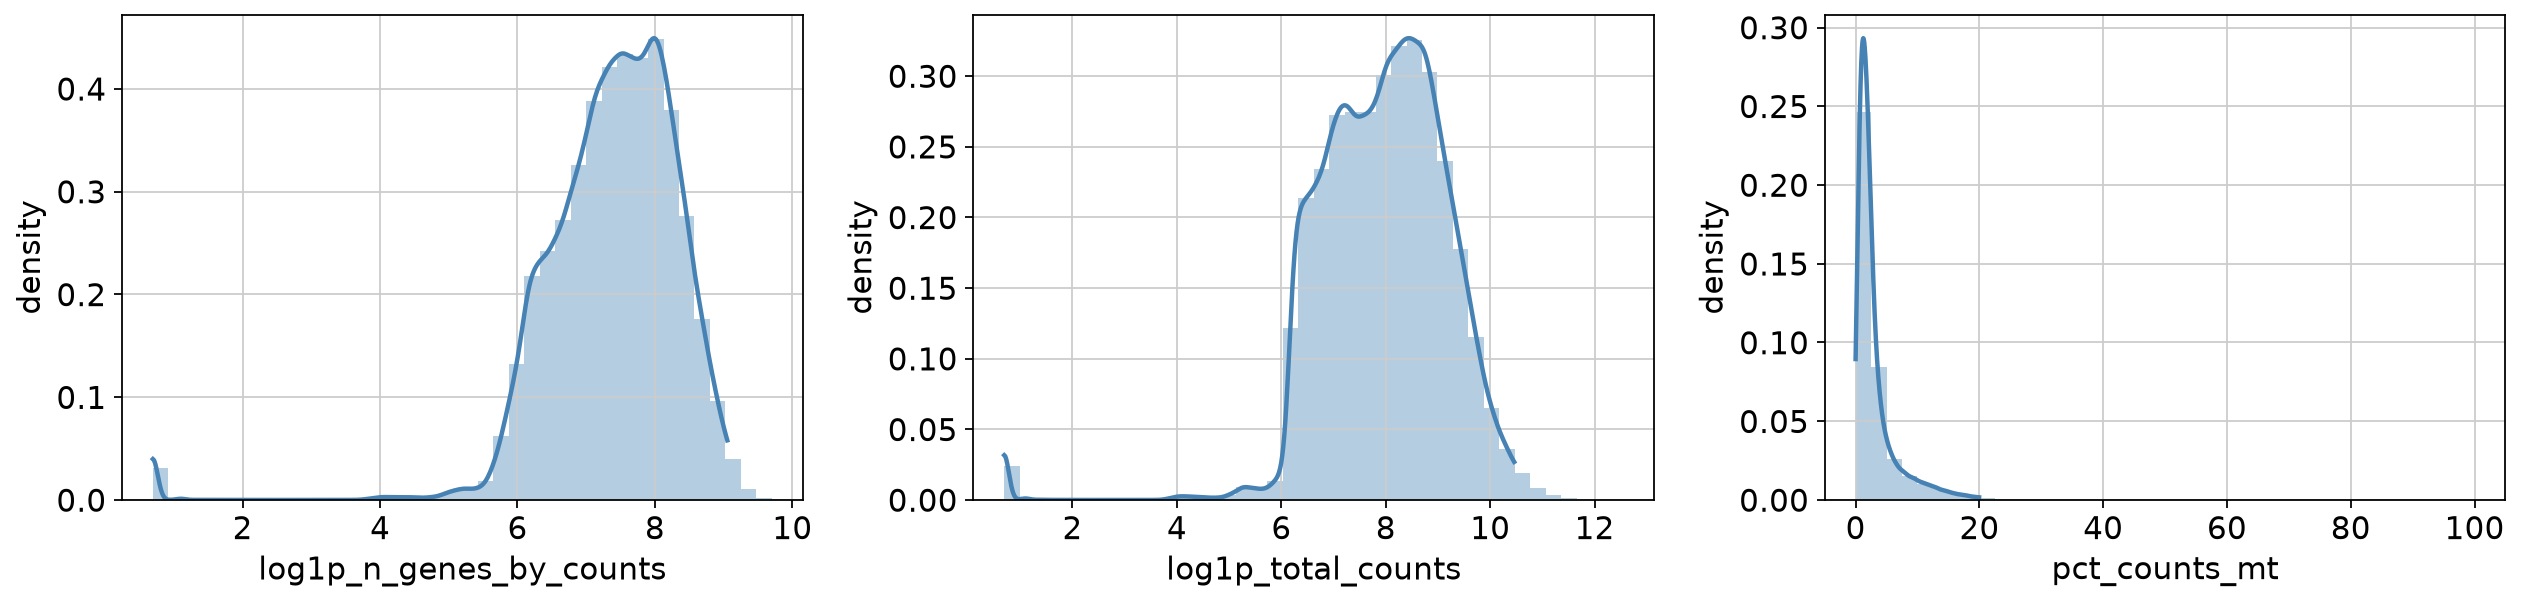

In [8]:
metrics = ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, metrics):
  vals = adata.obs[col].values
  ax.hist(vals, bins=40, density=True, alpha=0.4, color='steelblue')
  xgrid = np.linspace(vals.min(), np.percentile(vals, 99), 500)
  ax.plot(xgrid, gaussian_kde(vals)(xgrid), color='steelblue', lw=2)
  ax.set_xlabel(col)
  ax.set_ylabel('density')

fig.tight_layout()

In [9]:
adata = adata[
      (adata.obs['log1p_n_genes_by_counts'] > 5) &
      (adata.obs['log1p_n_genes_by_counts'] < 9.8) &
      (adata.obs['log1p_total_counts'] > 5.5) &
      (adata.obs['log1p_total_counts'] < 11) &
      (adata.obs['pct_counts_mt'] < 6)
  ]

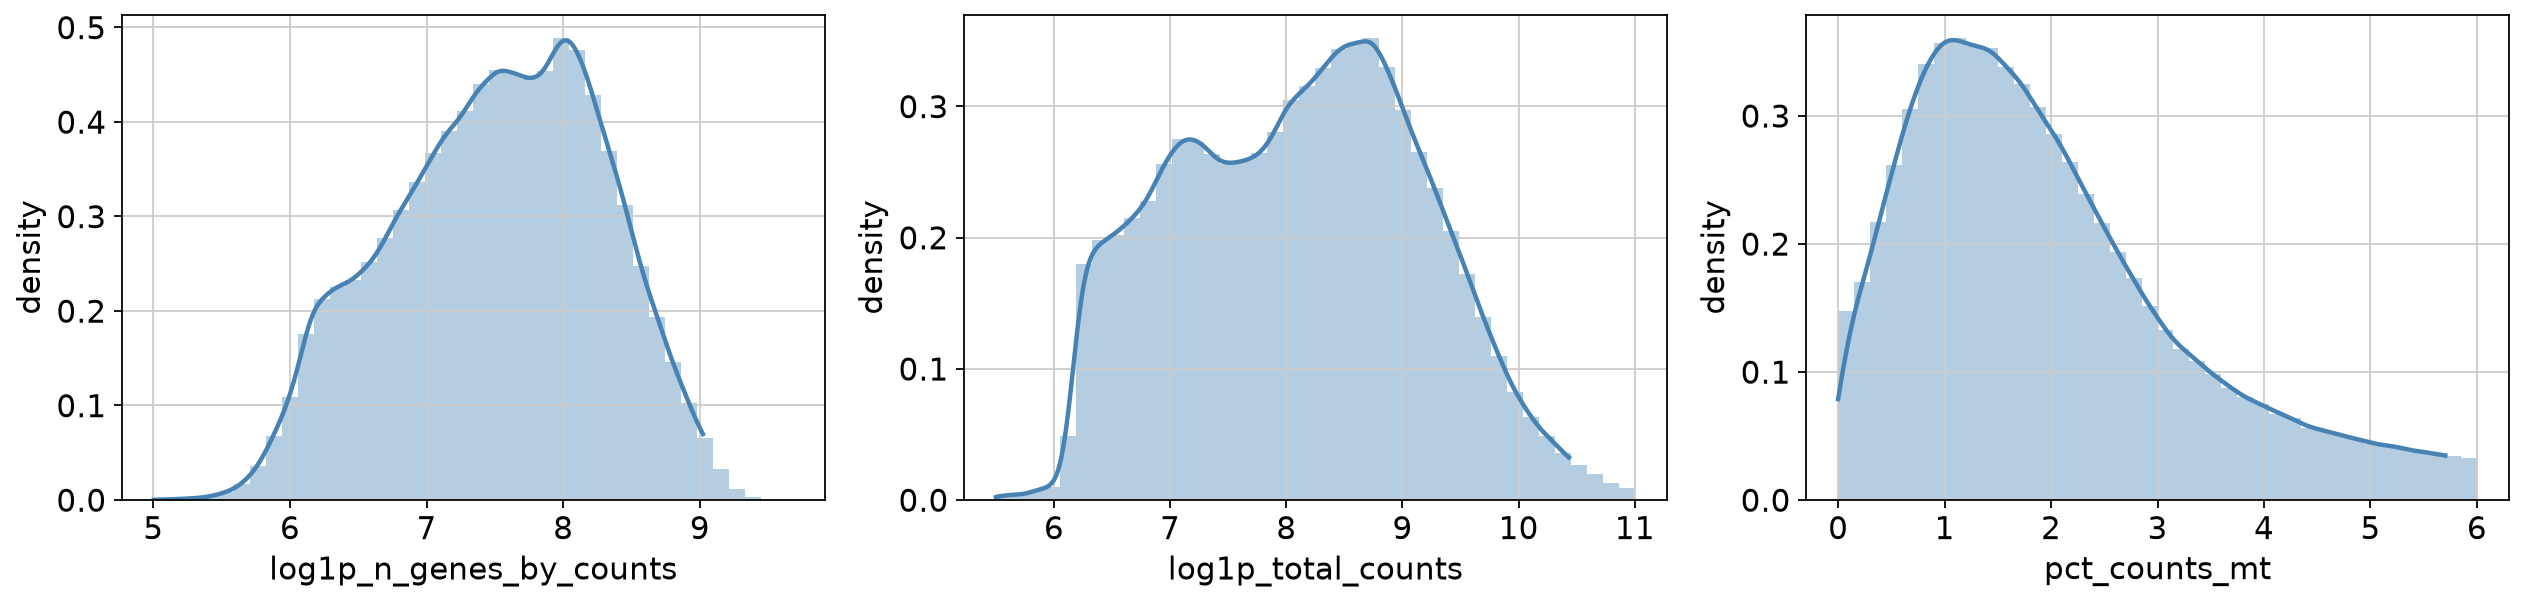

In [10]:
metrics = ['log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_mt']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, metrics):
  vals = adata.obs[col].values
  ax.hist(vals, bins=40, density=True, alpha=0.4, color='steelblue')
  xgrid = np.linspace(vals.min(), np.percentile(vals, 99), 500)
  ax.plot(xgrid, gaussian_kde(vals)(xgrid), color='steelblue', lw=2)
  ax.set_xlabel(col)
  ax.set_ylabel('density')

fig.tight_layout()

## Processing

In [11]:
rsc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)
rsc.pp.scale(adata, max_value=10, zero_center=False)
rsc.tl.pca(adata, svd_solver='arpack')
adata.obsm['X_pca_temp'] = adata.obsm['X_pca']

In [12]:
rmm.reinitialize(managed_memory=False, pool_allocator=True, devices=0)
cp.cuda.set_allocator(rmm_cupy_allocator)
rsc.pp.harmony_integrate(adata, key=["source_file", "TIS_ID"], flavor="harmony1")

In [13]:
rsc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, use_rep="X_pca_harmony", key_added="harmony")
rsc.tl.umap(adata, neighbors_key="harmony", key_added="X_umap_harmony", min_dist=0.001, spread=5)
rsc.tl.tsne(adata, n_pcs=40, early_exaggeration=12, learning_rate=200, use_rep="X_pca_harmony")
rsc.tl.leiden(adata, resolution=1.5, neighbors_key="harmony", key_added="leiden_harmony")

[2026-08-06 21:15:55.449] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


## Visualization 

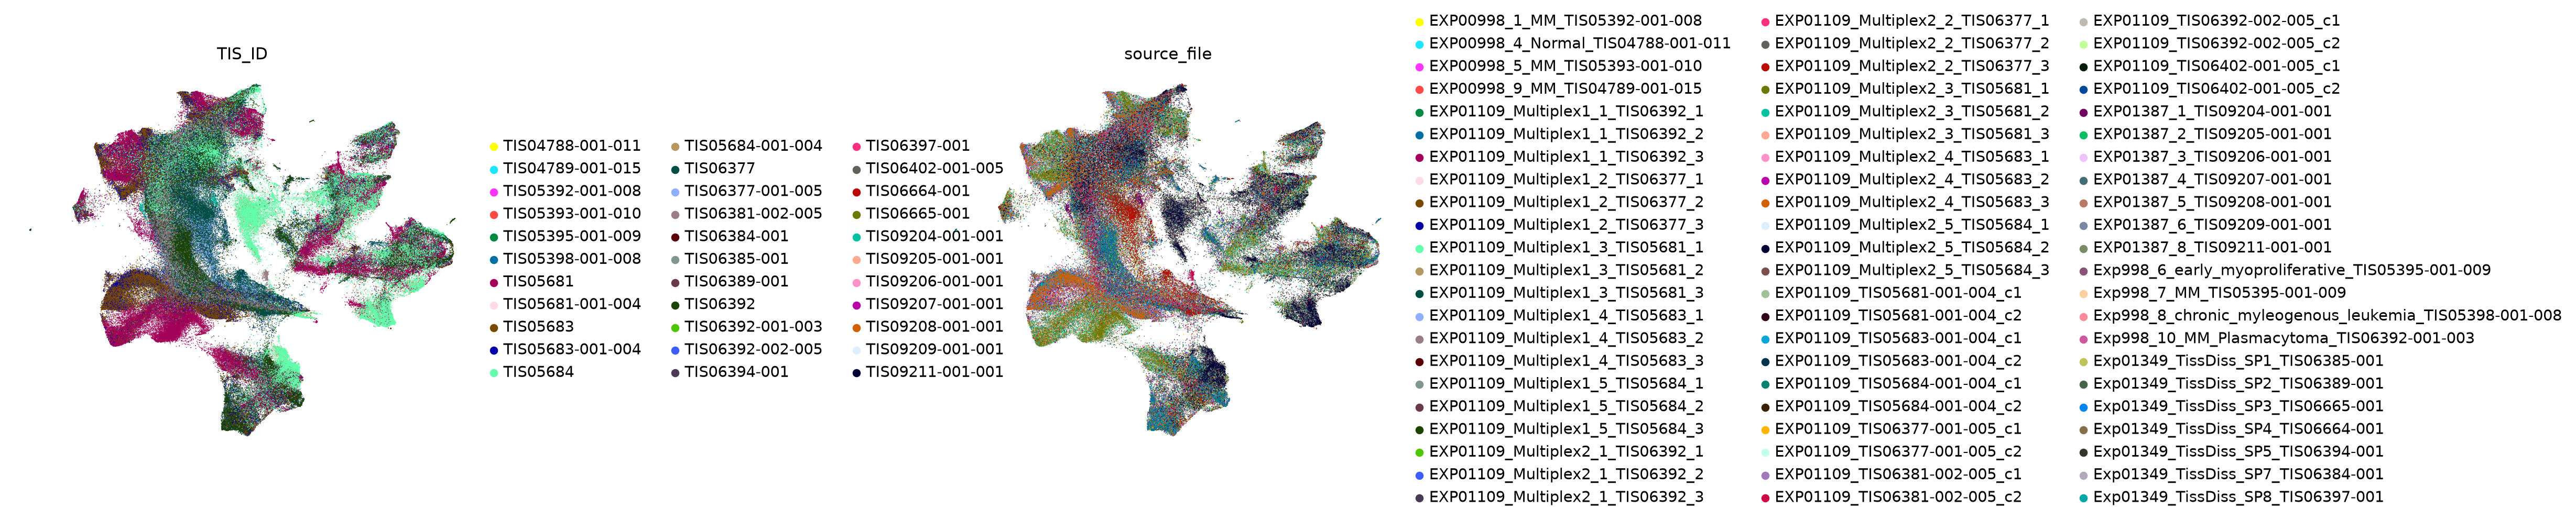

In [22]:
sc.pl.embedding(adata, basis="X_umap_harmony", color=["TIS_ID", "source_file"], wspace = 0.8, size=2)

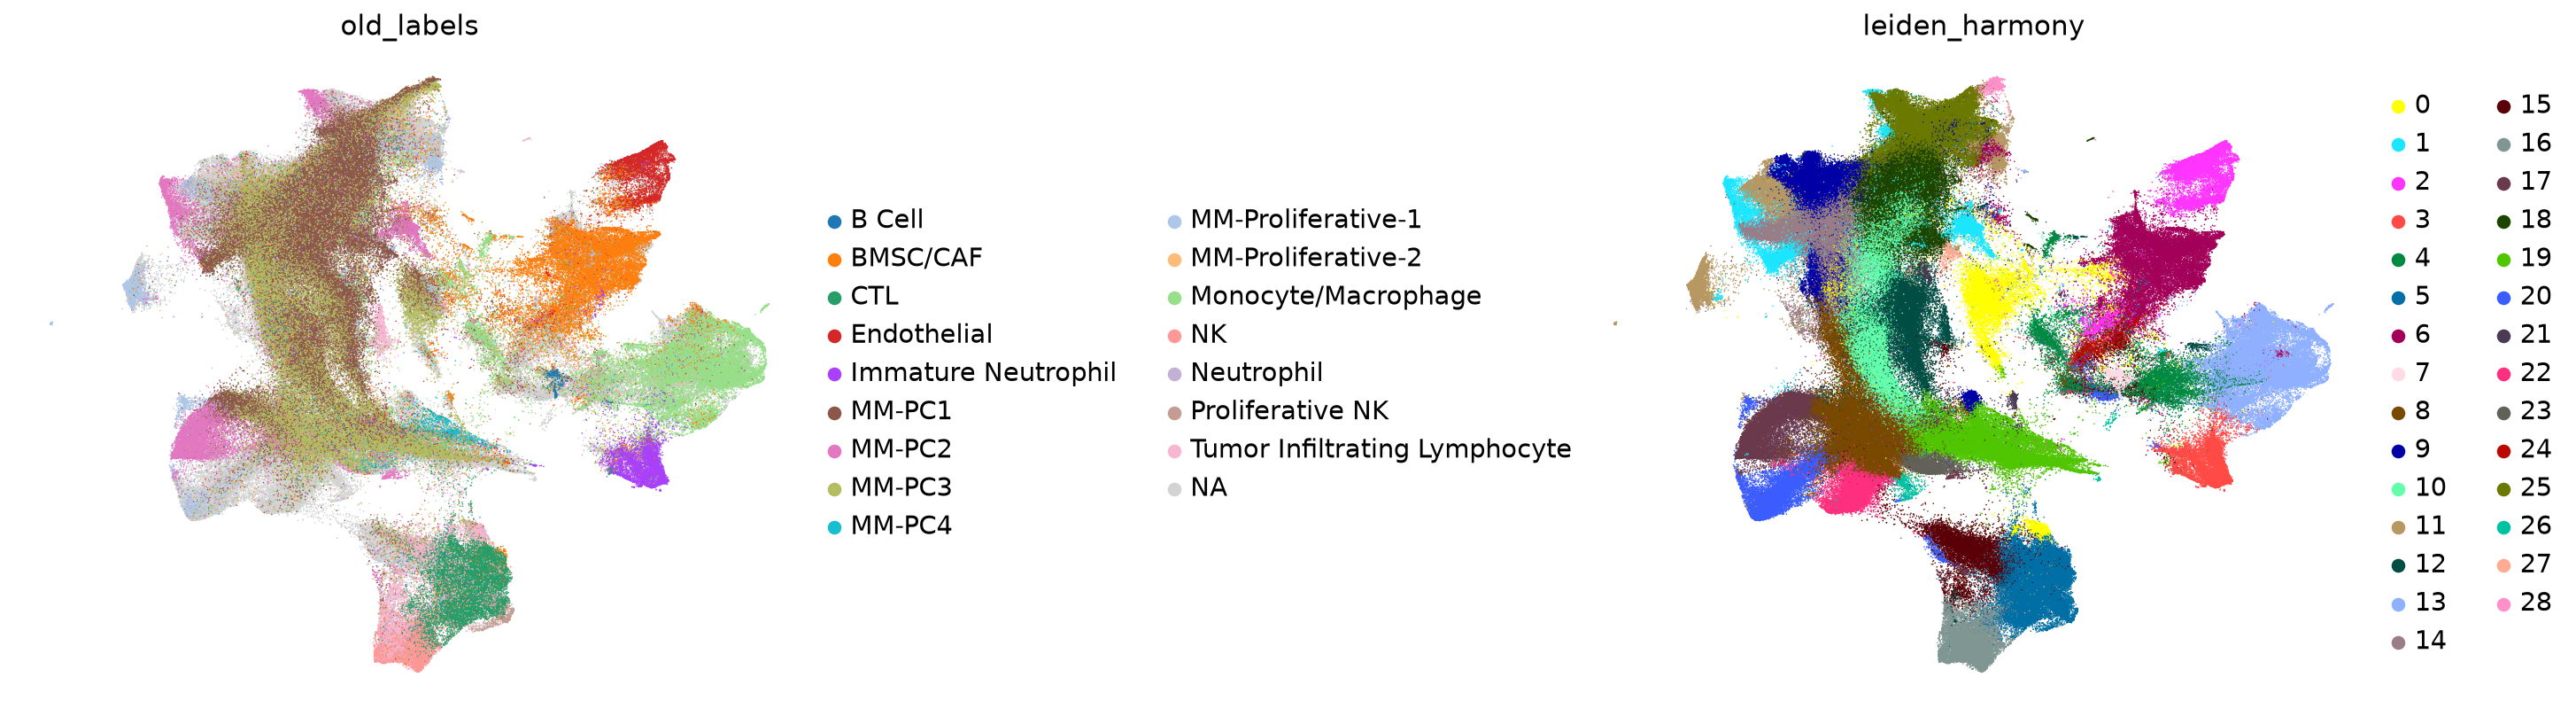

In [21]:
sc.pl.embedding(adata, basis="X_umap_harmony", color=["old_labels", "leiden_harmony"], wspace = 0.8, size=2)

## KNN Label Transfer

In [16]:
# KNN label transfer for unmatched (new) cells in shared Harmony PCA space
n_nbh = 100

adata.obs['knn_labels'] = adata.obs['old_labels']
X = adata.obsm['X_umap_harmony']
labels = adata.obs['knn_labels'].copy()
known  = labels.notna()
unknown = labels.isna()

knn = KNeighborsClassifier(n_neighbors=n_nbh, weights='distance', n_jobs=-1)
knn.fit(X[known], labels[known])

adata.obs.loc[unknown, 'knn_labels'] = knn.predict(X[unknown])

proba = knn.predict_proba(X[unknown])
adata.obs['knn_confidence'] = np.nan
adata.obs.loc[unknown, 'knn_confidence'] = proba.max(axis=1)

print("KNN predictions:")
print(adata.obs.loc[unknown, 'knn_labels'].value_counts())
print(adata.obs.loc[unknown, 'knn_confidence'].describe())

KNN predictions:
knn_labels
MM-PC3                           72158
MM-PC1                           27057
MM-Proliferative-1               16631
BMSC/CAF                         13478
Monocyte/Macrophage              12433
MM-PC2                            9115
CTL                               7367
Tumor Infiltrating Lymphocyte     3058
MM-Proliferative-2                2449
Endothelial                       2266
MM-PC4                            2260
Immature Neutrophil               1745
NK                                 858
B Cell                             678
Proliferative NK                   103
Neutrophil                           3
Name: count, dtype: int64
count    171659.000000
mean          0.581338
std           0.195877
min           0.126354
25%           0.426440
50%           0.568521
75%           0.726439
max           1.000000
Name: knn_confidence, dtype: float64


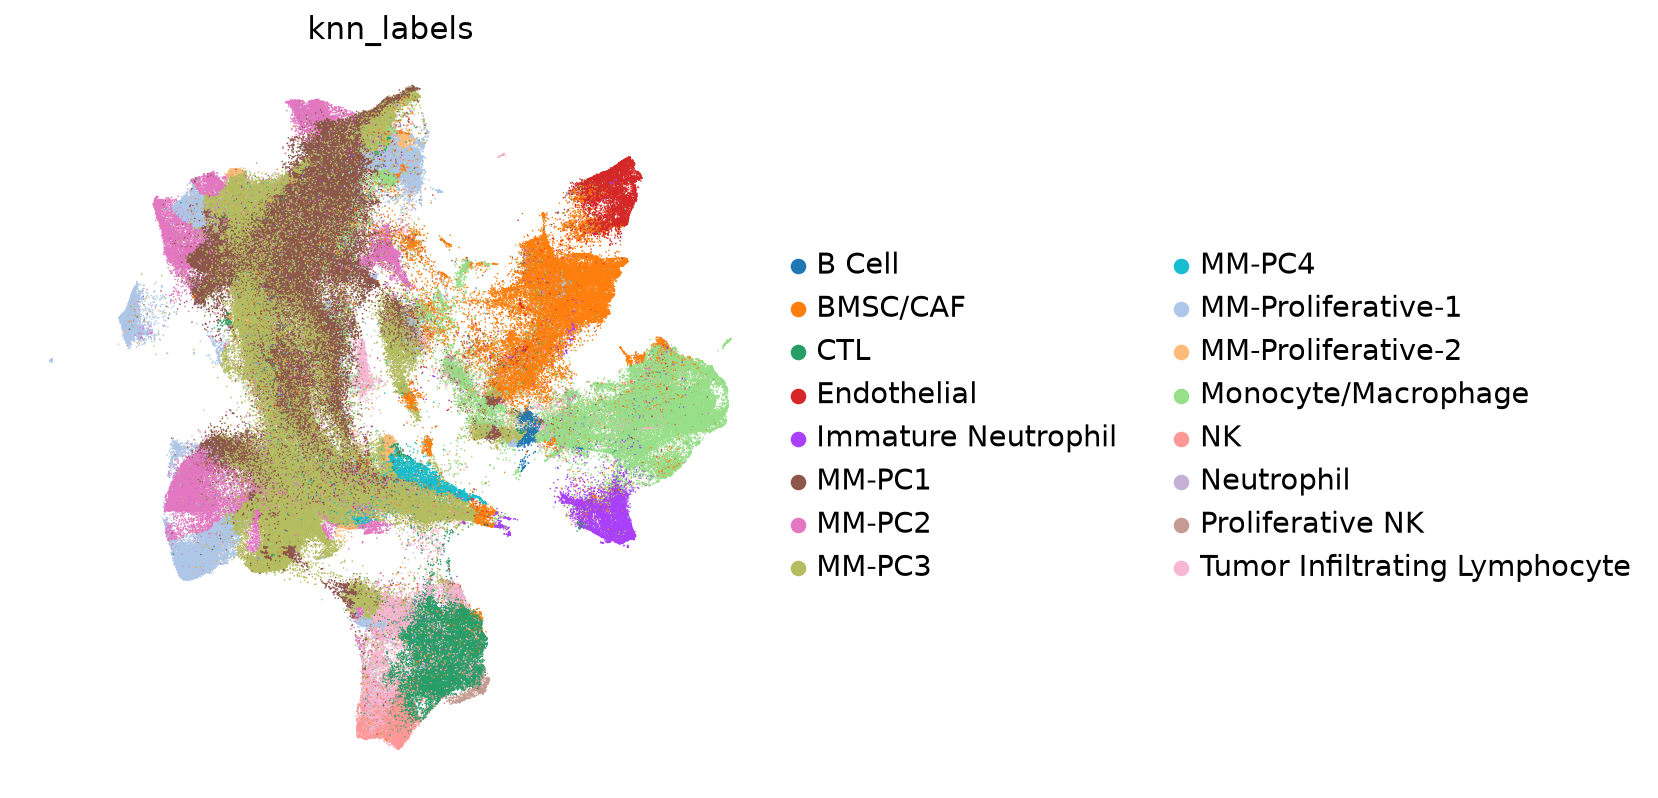

In [17]:
sc.pl.embedding(adata, basis="X_umap_harmony", color="knn_labels", size=2)

In [18]:
adata.write('../files/tissdiss_object.h5ad')

## Diffusion Maps

In [3]:
adata = sc.read_h5ad('../files/tissdiss_object.h5ad')

In [4]:
rsc.tl.diffmap(adata, neighbors_key="harmony")
# Due to an issue with plotting in Scanpy, we need to shift the first component of the diffusion map by removing the first column:
adata.obsm["X_diffmap"] = adata.obsm["X_diffmap"][:, 1:]

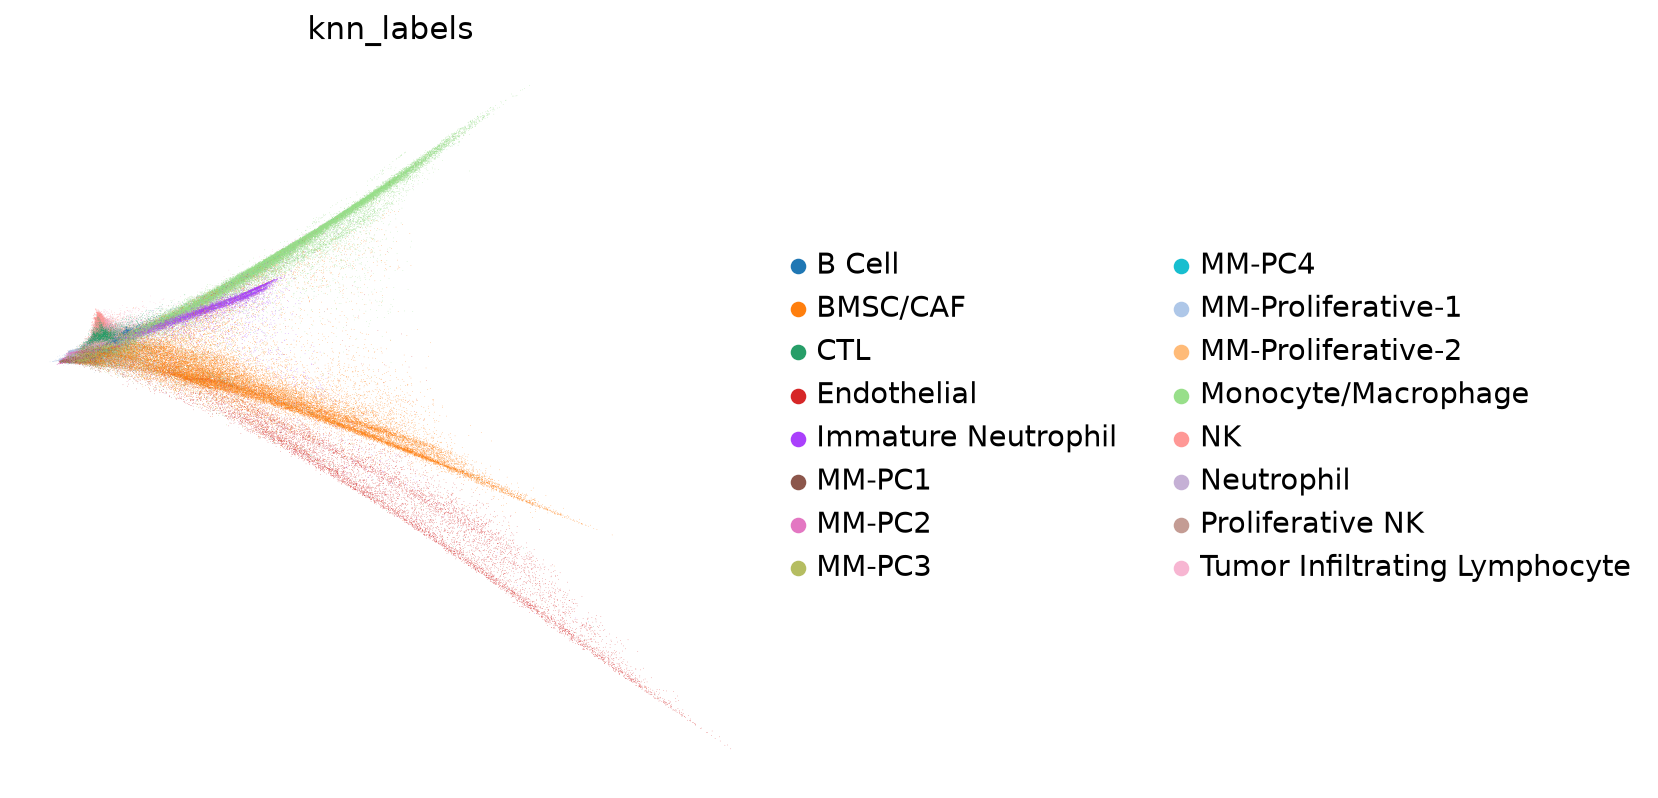

In [5]:
sc.pl.diffmap(adata, color="knn_labels")

## DEG Analysis

In [12]:
rsc.tl.rank_genes_groups(
    adata, groupby="knn_labels", method="t-test", key_added="ttest_knn_labels", use_raw=False
)

result = adata.uns['ttest_knn_labels']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:5]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj', 'scores']})

threshold = 0.05
significant_mask = pd.concat(
    [df[group + '_pvals'] < threshold for group in groups], axis=1).any(axis=1)
significant_df = df[significant_mask]
significant_df.head()
significant_df.to_csv('../files/rank_genes-ttest_knn_labels.csv')

In [13]:
rsc.tl.rank_genes_groups(
    adata, groupby="leiden_harmony", method="t-test", key_added="ttest_leiden_harmony", use_raw=False
)

result = adata.uns['ttest_leiden_harmony']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:5]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj', 'scores']})

threshold = 0.05
significant_mask = pd.concat(
    [df[group + '_pvals'] < threshold for group in groups], axis=1).any(axis=1)
significant_df = df[significant_mask]
significant_df.head()
significant_df.to_csv('../files/rank_genes-ttest_leiden_harmony.csv')

In [14]:
adata.write('../files/tissdiss_object_with_ranks.h5ad')

## Group fractions

In [21]:
pd.crosstab(      
      adata.obs['knn_labels'],
      adata.obs['leiden_harmony'],
      normalize='columns'  # fraction of each knn cluster
  ).style.background_gradient(cmap='Blues', axis=1)

leiden_harmony,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
knn_labels,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
B Cell,0.000457,0.000000,0.000324,0.001125,0.016058,0.000763,0.000038,0.639545,0.000437,0.000428,0.000267,0.000305,0.000000,0.000537,0.000231,0.006480,0.000344,0.000114,0.000072,0.000174,0.008854,0.000826,0.000179,0.000000,0.000752,0.000118,0.040541,0.000000,0.000570
BMSC/CAF,0.196540,0.007274,0.190214,0.024573,0.067120,0.019804,0.876276,0.034121,0.005302,0.006778,0.007484,0.009312,0.008489,0.053032,0.005859,0.046412,0.019169,0.007421,0.016565,0.051931,0.005777,0.281585,0.007325,0.006429,0.666291,0.010778,0.003378,0.000000,0.024501
CTL,0.006783,0.001251,0.004213,0.009473,0.005692,0.803954,0.002637,0.030184,0.003175,0.013205,0.001069,0.003817,0.001464,0.001832,0.002049,0.152195,0.139471,0.000970,0.001689,0.012295,0.001801,0.006606,0.006253,0.009001,0.003382,0.005949,0.002252,0.015714,0.001140
Endothelial,0.002439,0.000547,0.712006,0.000844,0.001444,0.001272,0.009871,0.001750,0.001107,0.001948,0.000611,0.001145,0.000703,0.002021,0.000837,0.001782,0.001099,0.000457,0.000575,0.002995,0.001276,0.001652,0.001787,0.003858,0.006764,0.002002,0.000000,0.000000,0.001709
Immature Neutrophil,0.002515,0.000860,0.007777,0.829488,0.009516,0.002071,0.007234,0.003937,0.002389,0.002610,0.001375,0.000763,0.000703,0.005717,0.001270,0.004131,0.000824,0.000799,0.001437,0.015151,0.005102,0.001652,0.001876,0.004501,0.001879,0.002739,0.138514,0.001429,0.001140
MM-PC1,0.161408,0.354685,0.019443,0.017445,0.057179,0.007813,0.012056,0.060805,0.130473,0.127955,0.607507,0.109534,0.545902,0.006728,0.548013,0.073222,0.009000,0.273033,0.763457,0.062311,0.035639,0.211396,0.119528,0.009430,0.096956,0.500736,0.009009,0.892857,0.460399
MM-PC2,0.012574,0.504067,0.011666,0.008254,0.014189,0.002035,0.006329,0.009186,0.043462,0.068399,0.013632,0.052362,0.007904,0.004232,0.059515,0.015390,0.005634,0.571641,0.016170,0.012713,0.059574,0.064410,0.035555,0.075654,0.007892,0.105130,0.078829,0.010000,0.001709
MM-PC3,0.400015,0.089629,0.028354,0.027387,0.108836,0.014390,0.019139,0.107174,0.784177,0.685701,0.324640,0.099382,0.303806,0.010897,0.363726,0.270533,0.013260,0.095445,0.146101,0.698095,0.143232,0.303881,0.805431,0.646592,0.155956,0.263561,0.643018,0.044286,0.458689
MM-PC4,0.003658,0.000391,0.002511,0.001501,0.001614,0.001272,0.000980,0.003937,0.005593,0.005804,0.001604,0.001527,0.001698,0.001105,0.002136,0.002025,0.001031,0.000628,0.000862,0.107798,0.000525,0.060281,0.000983,0.102229,0.002255,0.001090,0.001126,0.000000,0.000000


In [8]:
pd.crosstab(      
      adata.obs['leiden_harmony'],
      adata.obs['knn_labels'],
      normalize='index'  # fraction of each leiden cluster
  ).style.background_gradient(cmap='Reds', axis=1)

knn_labels,B Cell,BMSC/CAF,CTL,Endothelial,Immature Neutrophil,MM-PC1,MM-PC2,MM-PC3,MM-PC4,MM-Proliferative-1,MM-Proliferative-2,Monocyte/Macrophage,NK,Neutrophil,Proliferative NK,Tumor Infiltrating Lymphocyte
leiden_harmony,,,,,,,,,,,,,,,,
0,0.000457,0.196540,0.006783,0.002439,0.002515,0.161408,0.012574,0.400015,0.003658,0.042676,0.002286,0.073998,0.000381,0.000076,0.000305,0.093888
1,0.000000,0.007274,0.001251,0.000547,0.000860,0.354685,0.504067,0.089629,0.000391,0.027843,0.000313,0.008369,0.000782,0.000000,0.000078,0.003911
2,0.000324,0.190214,0.004213,0.712006,0.007777,0.019443,0.011666,0.028354,0.002511,0.005104,0.000972,0.011342,0.001620,0.000000,0.000324,0.004132
3,0.001125,0.024573,0.009473,0.000844,0.829488,0.017445,0.008254,0.027387,0.001501,0.004783,0.001125,0.068186,0.000657,0.000375,0.000000,0.004783
4,0.016058,0.067120,0.005692,0.001444,0.009516,0.057179,0.014189,0.108836,0.001614,0.004843,0.000425,0.660238,0.000680,0.000510,0.000255,0.051402
5,0.000763,0.019804,0.803954,0.001272,0.002071,0.007813,0.002035,0.014390,0.001272,0.005342,0.001563,0.007631,0.012500,0.000327,0.038592,0.080672
6,0.000038,0.876276,0.002637,0.009871,0.007234,0.012056,0.006329,0.019139,0.000980,0.031044,0.000565,0.027992,0.001017,0.000188,0.000339,0.004295
7,0.639545,0.034121,0.030184,0.001750,0.003937,0.060805,0.009186,0.107174,0.003937,0.009624,0.002625,0.049431,0.003062,0.000875,0.001750,0.041995
8,0.000437,0.005302,0.003175,0.001107,0.002389,0.130473,0.043462,0.784177,0.005593,0.006933,0.003117,0.009496,0.001020,0.000524,0.000087,0.002709


## Cluster views

In [4]:
adata

AnnData object with n_obs × n_vars = 471032 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'file_path', 'TIS_ID_base', 'in_cohort_metadata', 'flag', 'subject_id', 'cohort_label', 'tissue_type', 'sample_site', 'disease_state', 'age_at_collection', 'sex', 'race_ethnicity', 'treatment', 'pct_tumor', 'collection_year', 'biopsy_or_resection', 'old_labels', 'leiden_harmony', 'knn_labels', 'knn_confidence'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'TIS_ID_colors', 'X_umap_harmony', 'harmony', 'hvg', 'knn_labels_colors', 'leiden_harmony', 'leiden_harmony_colors', 'log1p', 'old_labels_colors', 'pca', 'source_file_colors', 'tsne'
    obsm: 'X_pca', 'X_pca_harmony', 'X_pca_temp', 'X_tsne', 'X_umap_harmony'
    varm: 'PCs'
    obsp: 'h

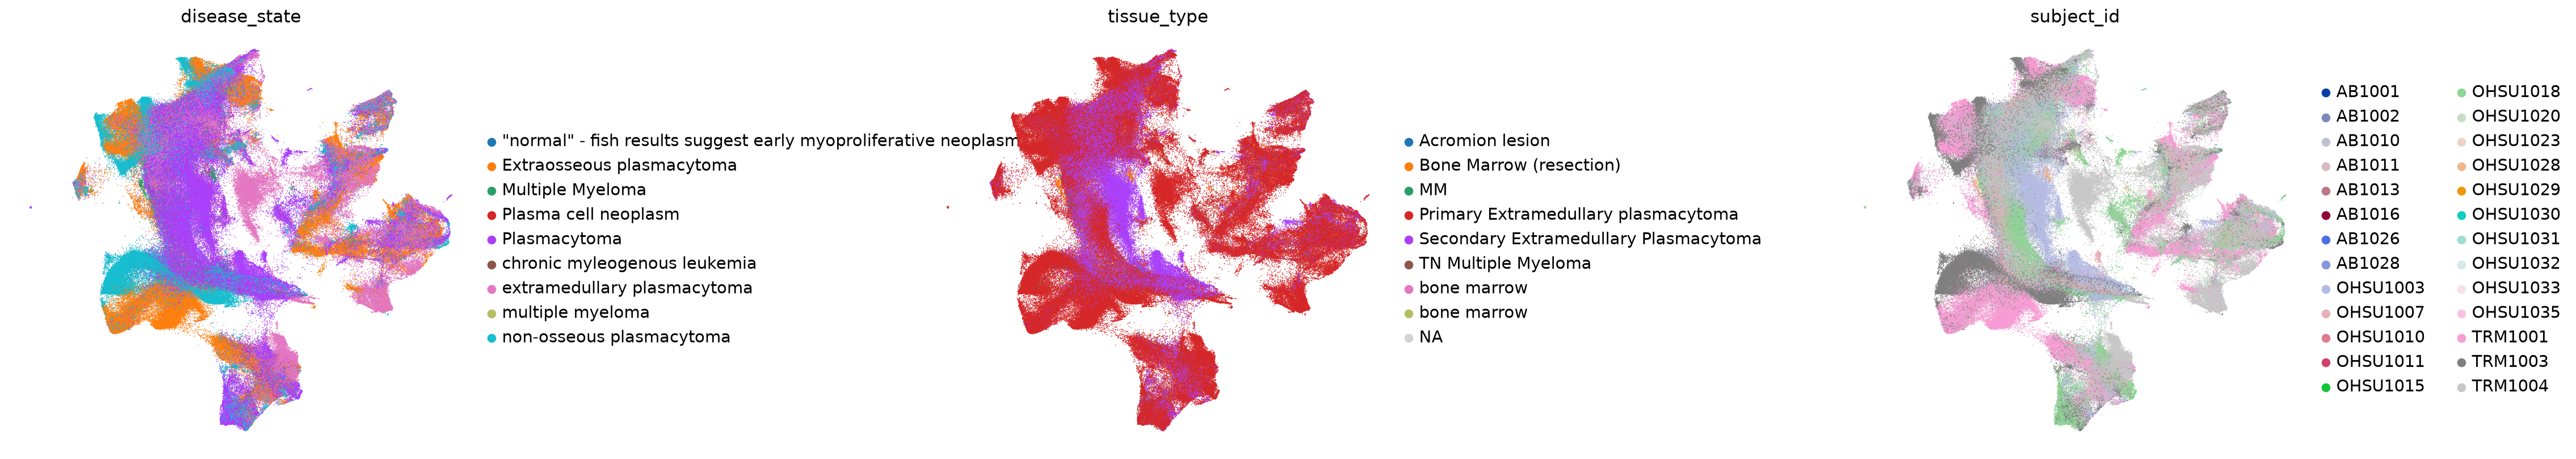

In [7]:
sc.pl.embedding(adata, basis='X_umap_harmony', color=['disease_state', 'tissue_type', 'subject_id'], size=2, wspace = 0.8)